# 🚢 End-to-End Exploratory Data Analysis (EDA) Project on Titanic Dataset

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Perform complete EDA on a real dataset.
- Apply data inspection techniques.
- Analyze missing values.
- Perform univariate, bivariate, and multivariate analysis.
- Study feature correlations.
- Create meaningful visualizations.
- Draw business insights.

## 📖 Project Overview

The Titanic dataset contains passenger information such as age, gender, ticket fare, passenger class, and survival status.

Our objective is not to build a machine learning model yet. Instead, we will understand the dataset thoroughly through Exploratory Data Analysis (EDA).

This process helps us identify patterns, detect issues, and prepare the data for future machine learning tasks.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [11]:
df.select_dtypes(include=["object"]).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

📌 Step 11: Univariate Analysis
Age Distribution

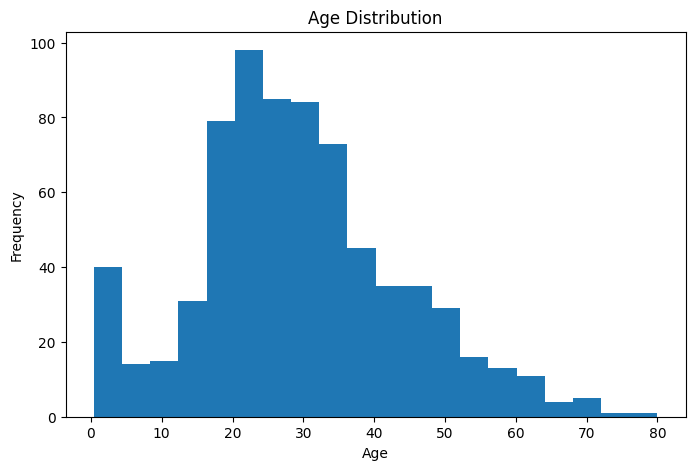

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"].dropna(), bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

Gender Distribution

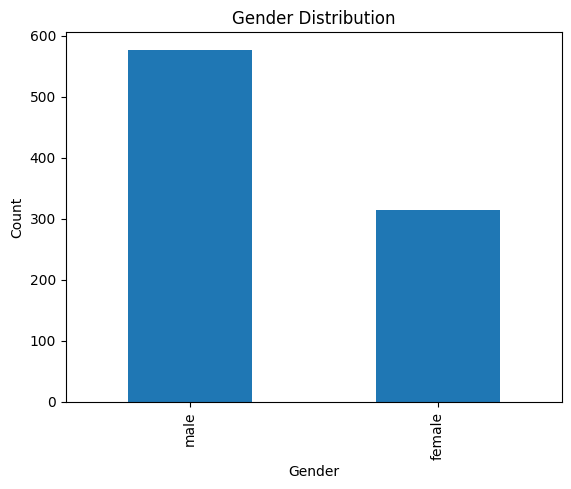

In [13]:
df["Sex"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

Passenger Class Distribution

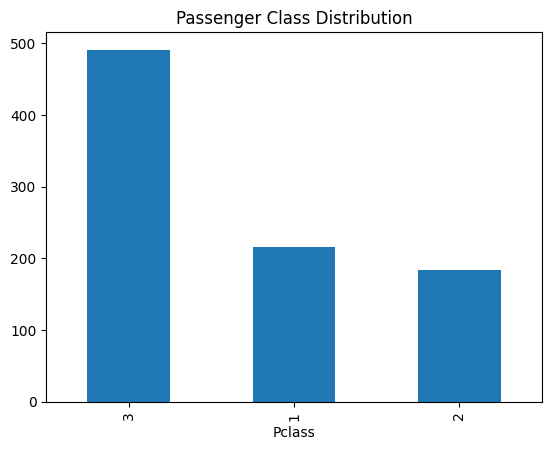

In [14]:
df["Pclass"].value_counts().plot(kind="bar")

plt.title("Passenger Class Distribution")

plt.show()

📌 Step 12: Bivariate Analysis
Survival by Gender

In [15]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


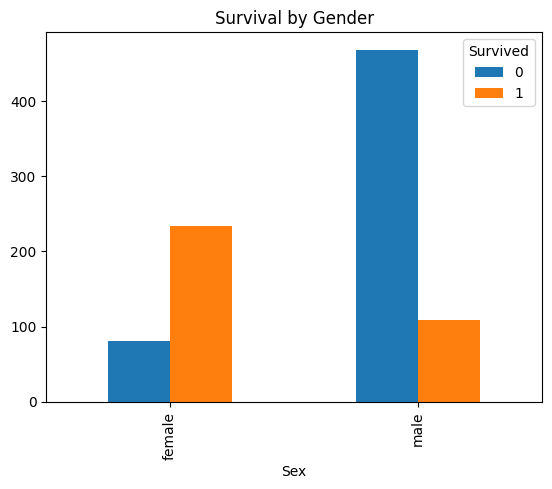

In [16]:
pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar")

plt.title("Survival by Gender")

plt.show()

Passenger Class vs Survival

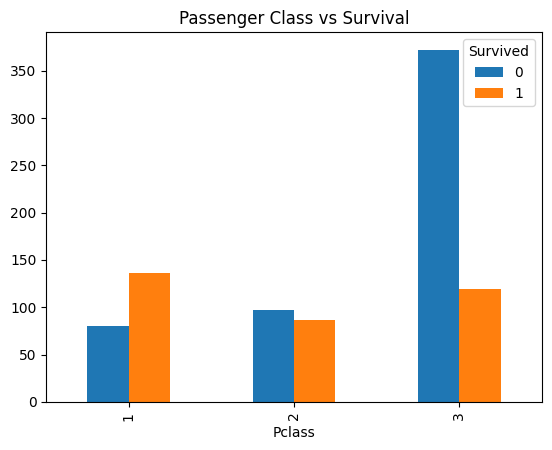

In [17]:
pd.crosstab(df["Pclass"], df["Survived"]).plot(kind="bar")

plt.title("Passenger Class vs Survival")

plt.show()

Average Fare by Passenger Class

In [18]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

📌 Step 13: Multivariate Analysis
Average Fare by Passenger Class and Gender

In [19]:
pd.pivot_table(
    df,
    values="Fare",
    index="Pclass",
    columns="Sex",
    aggfunc="mean"
)

Sex,female,male
Pclass,,
1,106.125798,67.226127
2,21.970121,19.741782
3,16.118810,12.661633


Survival Rate by Gender and Passenger Class

In [20]:
df.groupby(["Sex","Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

📌 Step 14: Correlation Analysis

In [21]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Correlation Matrix

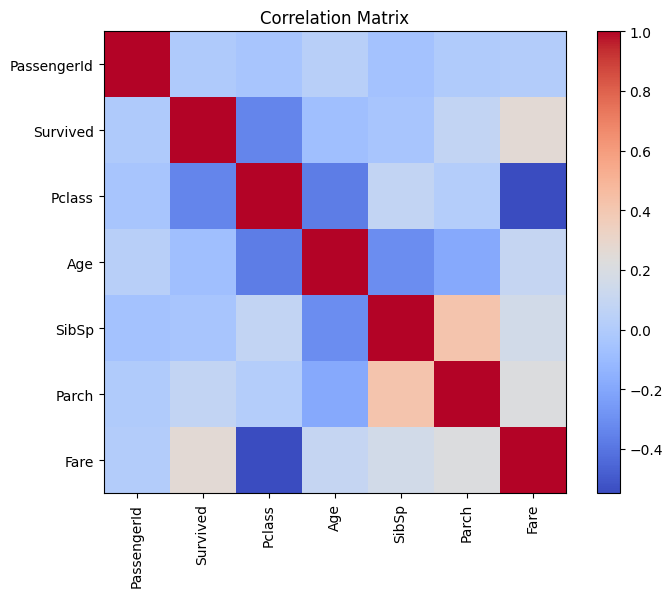

In [22]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

## 📊 Key Insights

1. Female passengers had a higher survival rate than male passengers.

2. First-class passengers survived more frequently than second- and third-class passengers.

3. Fare was generally higher for first-class passengers.

4. The Age feature contains missing values and should be cleaned before model building.

5. Cabin has a large number of missing values.

6. Passenger Class strongly influences Fare and Survival.

## 📝 Conclusion

Through this EDA project, we explored the Titanic dataset from multiple perspectives.

We identified missing values, examined feature distributions, studied relationships between variables, analyzed correlations, and generated meaningful business insights.

The dataset is now well understood and ready for preprocessing and machine learning.

## ✅ Best Practices

- Never skip EDA.
- Understand every feature before modeling.
- Handle missing values carefully.
- Verify assumptions using visualizations.
- Document insights throughout the analysis.

## 🌍 Real-World Scenario

Imagine you are a Data Analyst at an airline company. Before building a customer churn prediction model, you first inspect the dataset, identify missing values, analyze passenger demographics, compare customer groups, and visualize important trends. This process helps stakeholders understand the data and improves the quality of the predictive model.